In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import re
import time
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score, adjusted_rand_score


# Read and overview data

Here we use the encoded dataset from project_1 which was preprocessed and here because of the target of cluster by price so we do not need text here like problem 1

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/encoded_data_motobikes.csv')

In [ ]:
data.head(5)

,Thương hiệu,Dòng xe,Loại xe,Xuất xứ,Khoảng giá min,Khoảng giá max,Năm đăng ký,Số Km đã đi,Giá
0,13,52,1,7,72.53,85.14,2024,14000,66.0
1,8,42,1,7,62.76,73.68,2019,28000,79.5
2,8,53,1,7,28.00,32.86,2023,12000,37.0
3,13,52,1,7,43.10,50.60,2019,60000,45.0
4,17,13,1,2,17.02,19.98,2021,24000,23.0


Because data has many outliers and we want to apply K_means so we need scaler like RobustScaler

In [ ]:
X = np.array(data)
scaler = RobustScaler()
X = scaler.fit_transform(X)

# Kmeans Model

We can choose K by get log of the number of sample, log10(6923) ~ 3 or 4 (down approximate)

## Elbow method

In [ ]:
def elbow_methods(X = None, k_cluster = 2, random_state = 42):
  inertias = []
  k_values = list(range(1, k_cluster))

  for k in k_values:
    if k == 1:
      centroid = X.mean(axis = 0)
      inertia = np.sum((X - centroid)**2)
    else:
      kmeans = KMeans(n_clusters = k, random_state= random_state, n_init=10)
      kmeans.fit(X)
      inertia = kmeans.inertia_

    inertias.append(inertia)


  return {
      'k_values' : k_values,
      'inertias' : inertias
  }


In [ ]:
results = elbow_methods(X, 20, 42)
results_df = pd.DataFrame(results)
results_df.head(5)

,k_values,inertias
0,1,3.364190e+07
1,2,1.693408e+05
2,3,1.136372e+05
3,4,8.549988e+04
4,5,6.069655e+04


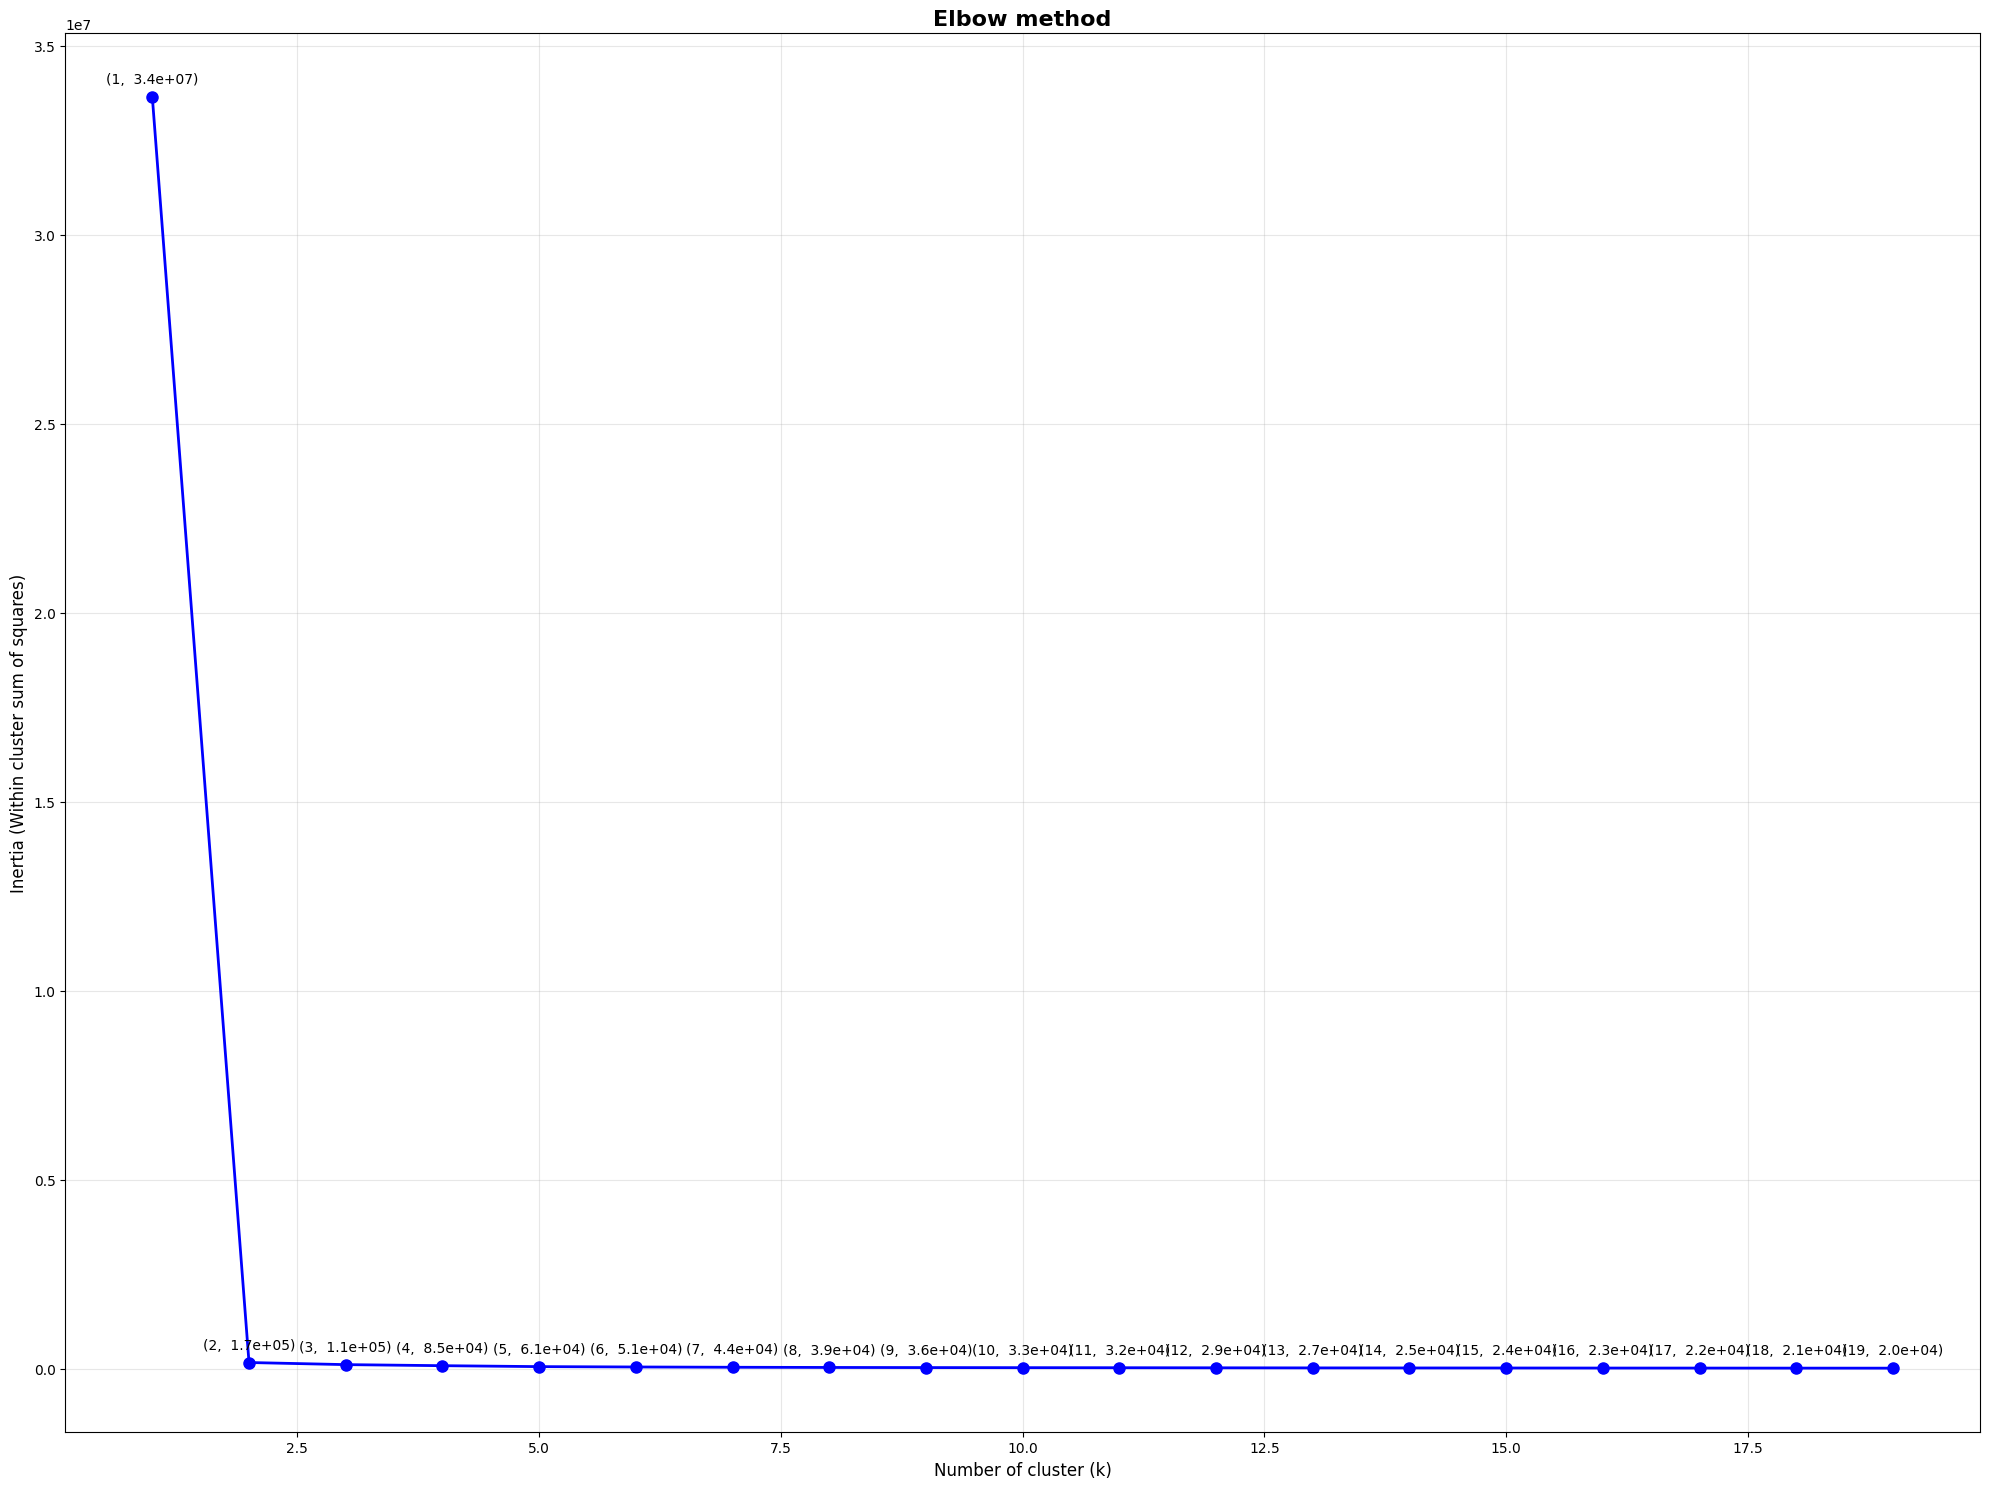

In [ ]:
fig, ax = plt.subplots(figsize = (20, 15))
ax.plot(results_df['k_values'], results_df['inertias'], 'bo-', linewidth = 2, markersize = 8)
ax.set_xlabel('Number of cluster (k)', fontsize = 12)
ax.set_ylabel('Inertia (Within cluster sum of squares)', fontsize = 12)
ax.set_title('Elbow method', fontsize = 16, fontweight = 'bold')
ax.grid(True, alpha = 0.3)

for (k, inertia) in zip(results_df['k_values'], results_df['inertias']):
  ax.annotate(f'({k}, {inertia : .{1}e})',
              (k, inertia), textcoords="offset points",
              xytext = (0, 10), ha = 'center')
plt.tight_layout()
plt.show()

According to elbow methods, k should be 3, actually in this domain 3 show the price like low, average and high which is reasonable

*   Mục danh sách
*   Mục danh sách



## Silhouette Analysis

In [ ]:
silhouete_results = []
k_clusters = list(range(2, 20))
for k in k_clusters:
  model = KMeans(n_clusters = k, random_state=42, n_init=10)
  labels = model.fit_predict(X)
  score = silhouette_score(X, labels)
  silhouete_results.append(score)
  print(f"k={k}: Silhouette Score = {score:.4f}")

k=2: Silhouette Score = 0.9990
k=3: Silhouette Score = 0.7338
k=4: Silhouette Score = 0.5978
k=5: Silhouette Score = 0.5700
k=6: Silhouette Score = 0.4838
k=7: Silhouette Score = 0.4927
k=8: Silhouette Score = 0.2481
k=9: Silhouette Score = 0.2196
k=10: Silhouette Score = 0.2153
k=11: Silhouette Score = 0.1839
k=12: Silhouette Score = 0.1833
k=13: Silhouette Score = 0.1872
k=14: Silhouette Score = 0.2008
k=15: Silhouette Score = 0.1789
k=16: Silhouette Score = 0.1830
k=17: Silhouette Score = 0.1891
k=18: Silhouette Score = 0.1910
k=19: Silhouette Score = 0.1887


In [ ]:
# Find optimal k from silhouette analysis
optimal_k_silhouette = list(k_clusters)[np.argmax(silhouete_results)]
print(f"\n Optimal k from silhouette analysis: {optimal_k_silhouette}")
print(f"   Best silhouette score: {max(silhouete_results):.4f}")


 Optimal k from silhouette analysis: 2
   Best silhouette score: 0.9990


As We can see that, k = 3 or k = 4 is just fine, with k=2 (best score) but it may overfit for the data and hard to explain

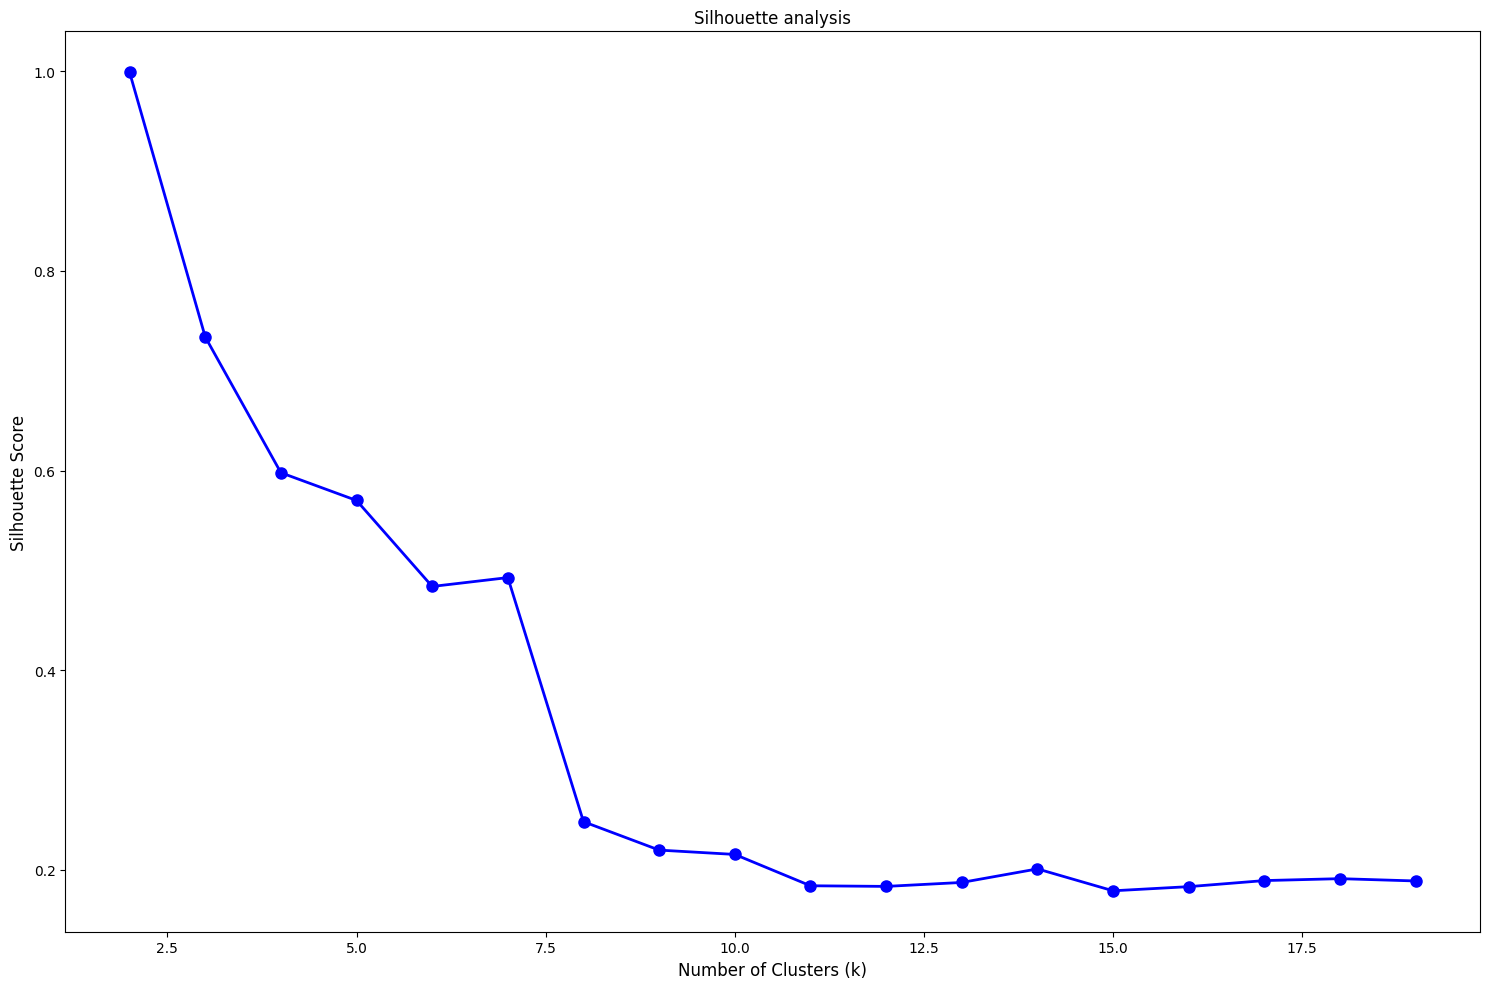

In [ ]:
plt.figure(figsize = (15, 10))
plt.plot(k_clusters, silhouete_results,'-bo' , linewidth = 2, markersize = 8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette analysis')
plt.tight_layout()
plt.show()

With k = 3

In [ ]:
kmeans_optimal = KMeans(n_clusters = 3, random_state=42, n_init = 10)
kmeans_optimal.fit(X)

labels_kmeans = kmeans_optimal.labels_
centroids_kmeans = kmeans_optimal.cluster_centers_
inertia_kmeans = kmeans_optimal.inertia_

print(f"   Final inertia: {inertia_kmeans:.{3}e}")
print(f"   Number of iterations: {kmeans_optimal.n_iter_}")
print(f"Number in each cluster: {np.bincount(labels_kmeans)}")

   Final inertia: 1.136e+05
   Number of iterations: 14
Number in each cluster: [6633    1  289]


With k = 4

In [ ]:
kmeans_optimal = KMeans(n_clusters = 4, random_state=42, n_init = 10)
kmeans_optimal.fit(X)

labels_kmeans = kmeans_optimal.labels_
centroids_kmeans = kmeans_optimal.cluster_centers_
inertia_kmeans = kmeans_optimal.inertia_

print(f"   Final inertia: {inertia_kmeans:.{3}e}")
print(f"   Number of iterations: {kmeans_optimal.n_iter_}")
print(f"Number in each cluster: {np.bincount(labels_kmeans)}")

   Final inertia: 8.550e+04
   Number of iterations: 9
Number in each cluster: [6077    1  558  287]


## Using PCA and TSNE for visualizarion

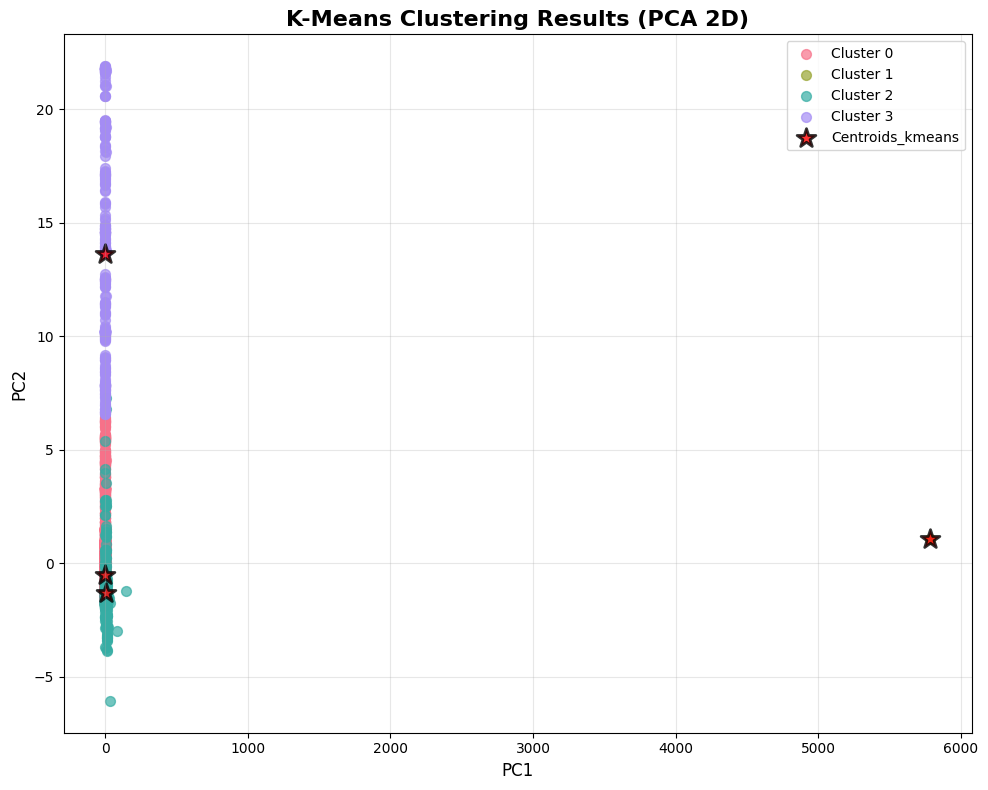

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10,8))

unique_labels = np.unique(labels_kmeans)
colors = sns.color_palette("husl", len(unique_labels))

for i, label in enumerate(unique_labels):
    if label == -1:
        color = 'black'
        marker = 'x'
        alpha = 0.5
    else:
        color = colors[i]
        marker = 'o'
        alpha = 0.7

    mask = labels_kmeans == label      # <-- dùng labels_kmeans
    ax.scatter(X_pca[mask, 0],         # <-- dùng PCA data
               X_pca[mask, 1],
               c=[color], marker=marker, alpha=alpha, s=50,
               label=f'Cluster {label}' if label != -1 else 'Outliers')

# Plot centroids (also converted to PCA space)
if centroids_kmeans is not None:
    centroids_pca = pca.transform(centroids_kmeans)   # cần transform centroids luôn
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
               c='red', marker='*', s=200, alpha=0.8,
               edgecolors='black', linewidth=2, label='Centroids_kmeans')

ax.set_title("K-Means Clustering Results (PCA 2D)", fontsize=16, fontweight='bold')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


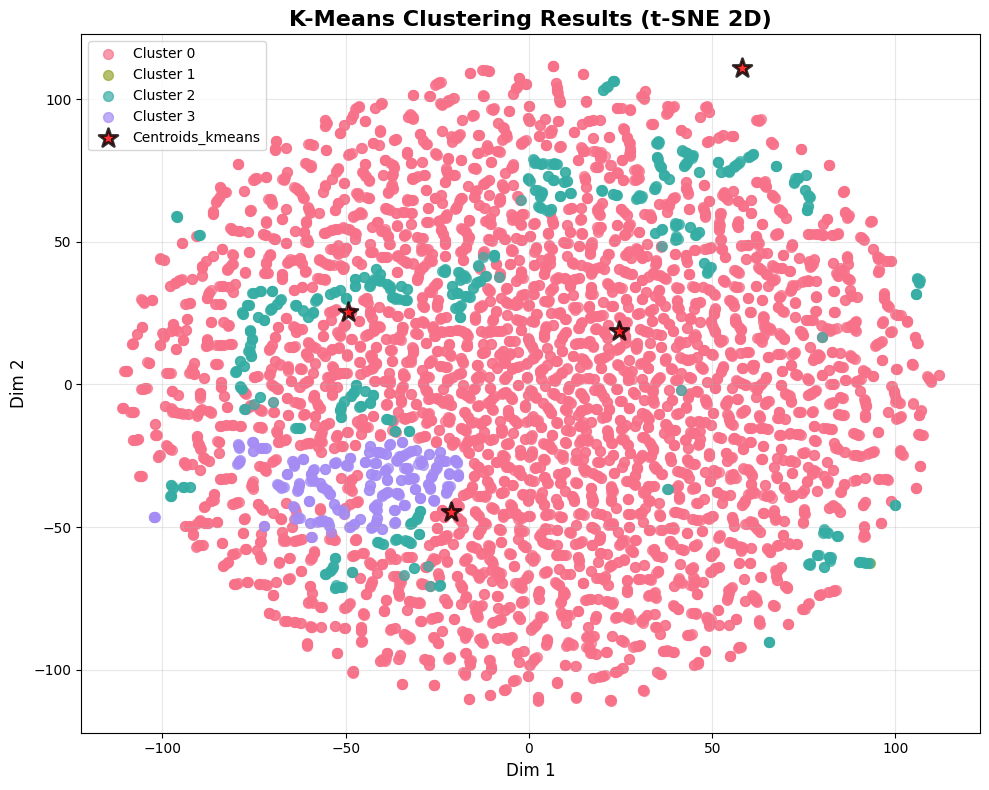

In [ ]:
tsne = TSNE(n_components=2, perplexity=2, learning_rate='auto', init='random')
X_tsne = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(10,8))

unique_labels = np.unique(labels_kmeans)
colors = sns.color_palette("husl", len(unique_labels))

for i, label in enumerate(unique_labels):
    if label == -1:
        color = 'black'
        marker = 'x'
        alpha = 0.5
    else:
        color = colors[i]
        marker = 'o'
        alpha = 0.7

    mask = labels_kmeans == label
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[color],
        marker=marker,
        alpha=alpha,
        s=50,
        label=f'Cluster {label}' if label != -1 else 'Outliers'
    )

# Plot centroids (also transformed by t-SNE)
if centroids_kmeans is not None:
    centroids_tsne = tsne.fit_transform(centroids_kmeans)  # Note: TSNE can't transform → must fit again
    ax.scatter(
        centroids_tsne[:, 0],
        centroids_tsne[:, 1],
        c='red',
        marker='*',
        s=200,
        alpha=0.8,
        edgecolors='black',
        linewidth=2,
        label='Centroids_kmeans'
    )

ax.set_title("K-Means Clustering Results (t-SNE 2D)", fontsize=16, fontweight='bold')
ax.set_xlabel('Dim 1', fontsize=12)
ax.set_ylabel('Dim 2', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gaussian Mixture

## Using AIC/BIC metrics

In [ ]:
k_range = 10
aic_values = []
bic_values = []
k_values = list(range(1, k_range))

for k in k_values:
    try:
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm.fit(X)

        aic_values.append(gmm.aic(X))
        bic_values.append(gmm.bic(X))
    except Exception as e:
        print(f"Error fitting GMM with k={k}: {e}")
        aic_values.append(float('inf'))
        bic_values.append(float('inf'))

results = {
    'k_values': k_values,
    'aic_values': aic_values,
    'bic_values': bic_values
}
print(f"AIC/BIC analysis tested k values: {results['k_values']}")

AIC/BIC analysis tested k values: [1, 2, 3, 4, 5, 6, 7, 8, 9]


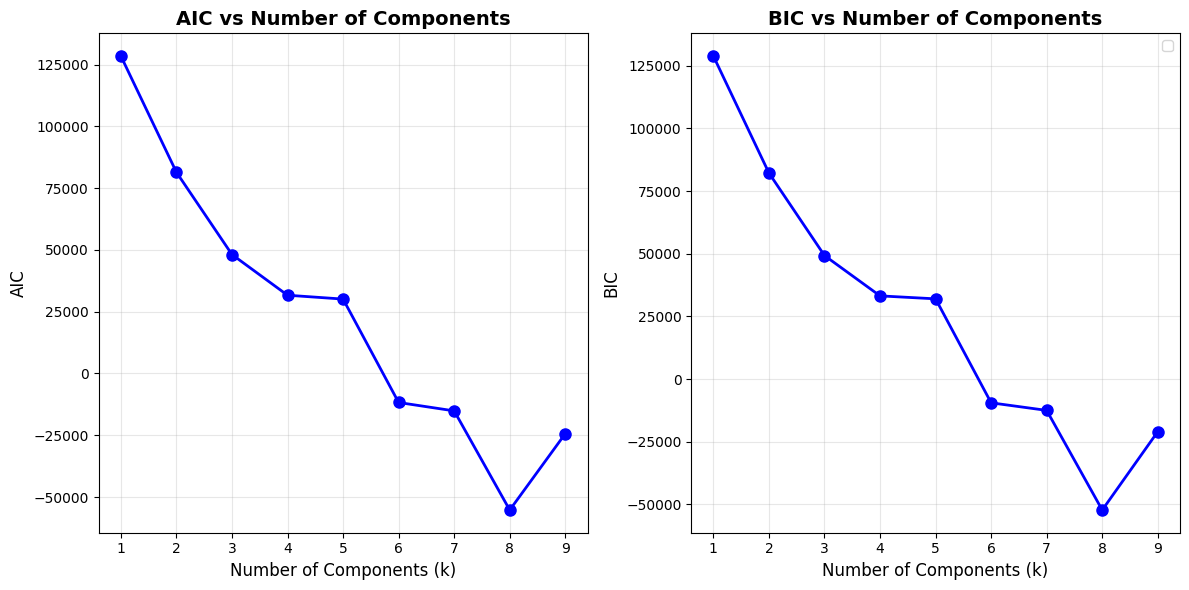

In [ ]:
plt.figure(figsize = (12, 6))

plt.subplot(1, 2, 1)
plt.plot(results['k_values'], results['aic_values'], '-bo', linewidth = 2, markersize = 8)
plt.xlabel('Number of Components (k)', fontsize=12)
plt.ylabel('AIC', fontsize=12)
plt.title('AIC vs Number of Components', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(results['k_values'], results['bic_values'], '-bo', linewidth = 2, markersize = 8)
plt.xlabel('Number of Components (k)', fontsize=12)
plt.ylabel('BIC', fontsize=12)
plt.title('BIC vs Number of Components', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)


plt.legend()
plt.tight_layout()
plt.show()

## Using Silhouete score

In [ ]:
import time

gmm_silhouete_results = []
k_values = list(range(2,20))

for k in k_values:

  gmm = GaussianMixture(n_components=k, random_state = 42)
  gmm_labels = gmm.fit_predict(X)
  silhouete_score = silhouette_score(X, gmm_labels)
  gmm_silhouete_results.append(silhouete_score)

  print(f"k={k}: GMM Silhouette Score = {silhouete_score:.4f}")

print(f"\n Optimal k from GMM silhouette analysis: {k_values[np.argmax(gmm_silhouete_results)]}")


k=2: GMM Silhouette Score = 0.9990
k=3: GMM Silhouette Score = 0.2792
k=4: GMM Silhouette Score = 0.3344
k=5: GMM Silhouette Score = 0.3277
k=6: GMM Silhouette Score = 0.0447
k=7: GMM Silhouette Score = 0.0392
k=8: GMM Silhouette Score = 0.0141
k=9: GMM Silhouette Score = 0.0543
k=10: GMM Silhouette Score = -0.0069
k=11: GMM Silhouette Score = -0.0009
k=12: GMM Silhouette Score = -0.0010
k=13: GMM Silhouette Score = 0.0030
k=14: GMM Silhouette Score = -0.0261
k=15: GMM Silhouette Score = -0.0436
k=16: GMM Silhouette Score = -0.0705
k=17: GMM Silhouette Score = -0.0062
k=18: GMM Silhouette Score = -0.0469
k=19: GMM Silhouette Score = -0.0293

 Optimal k from GMM silhouette analysis: 2


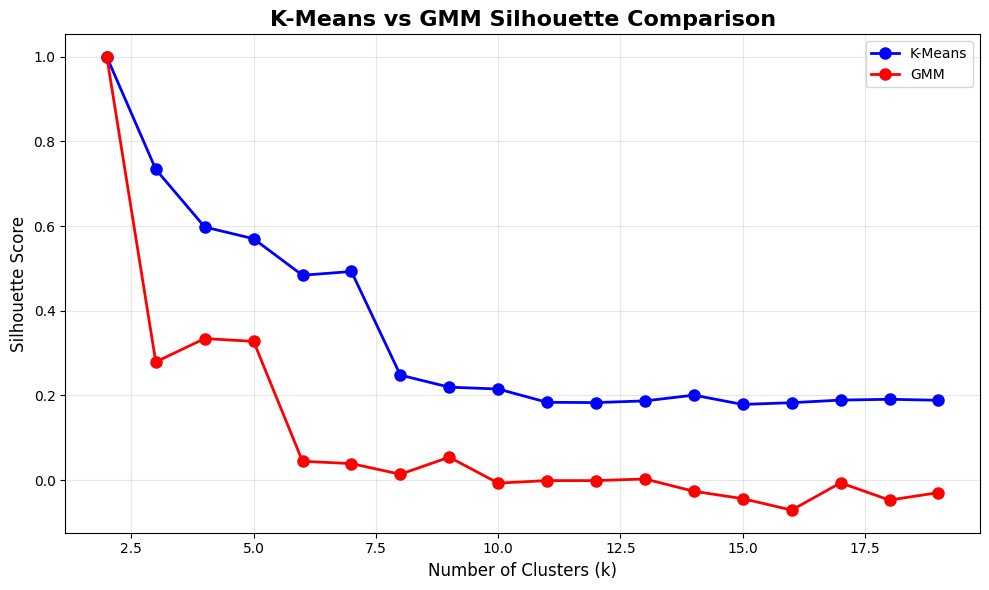

In [ ]:
# Compare K-Means vs GMM silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_clusters, silhouete_results, 'bo-', linewidth=2, label='K-Means', markersize=8)
plt.plot(k_values, gmm_silhouete_results, 'ro-', linewidth=2, label='GMM', markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('K-Means vs GMM Silhouette Comparison', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
gmm_optimal = GaussianMixture(n_components = 4, random_state = 42)
gmm_optimal.fit(X)

print(f'GMM results')
print(f' Converged: {gmm_optimal.converged_}')
print(f' Num of iterations: {gmm_optimal.n_iter_}')
print(f' Log-likelihood : {gmm_optimal.score(X) :.2f}')
print(f' AIC: {gmm_optimal.aic(X):.2f}')
print(f' AIC: {gmm_optimal.bic(X):.2f}')

GMM results
 Converged: True
 Num of iterations: 14
 Log-likelihood : -2.26
 AIC: 31679.02
 AIC: 33177.55


In [ ]:
# Display GMM parameters
print("\nGMM Parameters:")
print(f"   Component weights: {gmm_optimal.weights_}")
print(f"   Component means:")
for i, mean in enumerate(gmm_optimal.means_):
    print(f"      Component {i}: [{mean[0]:.3f}, {mean[1]:.3f}, {mean[2]:.3f}, {mean[3]:.3f}]")

print(f"   Component covariances shape:{gmm_optimal.covariances_.shape}")


GMM Parameters:
   Component weights: [1.37705276e-01 1.44446049e-04 6.53902908e-01 2.08247371e-01]
   Component means:
      Component 0: [0.142, 0.288, -0.147, -0.347]
      Component 1: [0.000, 0.368, 0.000, 0.000]
      Component 2: [0.505, 0.050, 0.123, -0.353]
      Component 3: [0.364, -0.113, 0.265, -0.520]
   Component covariances shape:(4, 9, 9)
